In [1]:
import kaggle 
import os
import zipfile
import pandas as pd
import math
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
import matplotlib.pyplot as plt
import seaborn as sns
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_rows', 100) 
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None) 
pd.set_option('display.max_colwidth', None)

# Tải và giải nén dataset

In [2]:
output_path = "../data/raw"
os.makedirs(output_path, exist_ok=True)
kaggle.api.competition_download_files('house-prices-advanced-regression-techniques', path=output_path)
zip_file = os.path.join(output_path, "house-prices-advanced-regression-techniques.zip")
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(output_path)
    os.remove(zip_file)

# Đọc dataset

Từ kết quả đọc dataset ta thấy dataset này 1460 mẫu dữ liệu, 80 thuộc tính. Một số mẫu có giá trị NA.

In [3]:
output_path = "../data/raw"
train_df = pd.read_csv(os.path.join(output_path,'train.csv'))
test_df = pd.read_csv(os.path.join(output_path,'test.csv'))
train_df = train_df.drop(['Id'],axis=1)
test_df = test_df.drop(['Id'],axis=1)
train_df.shape
train_df.info()
train_df.describe()

(1460, 80)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


C:\Users\minhh\AppData\Local\Temp\ipykernel_6824\1871719995.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object', 'category']).columns


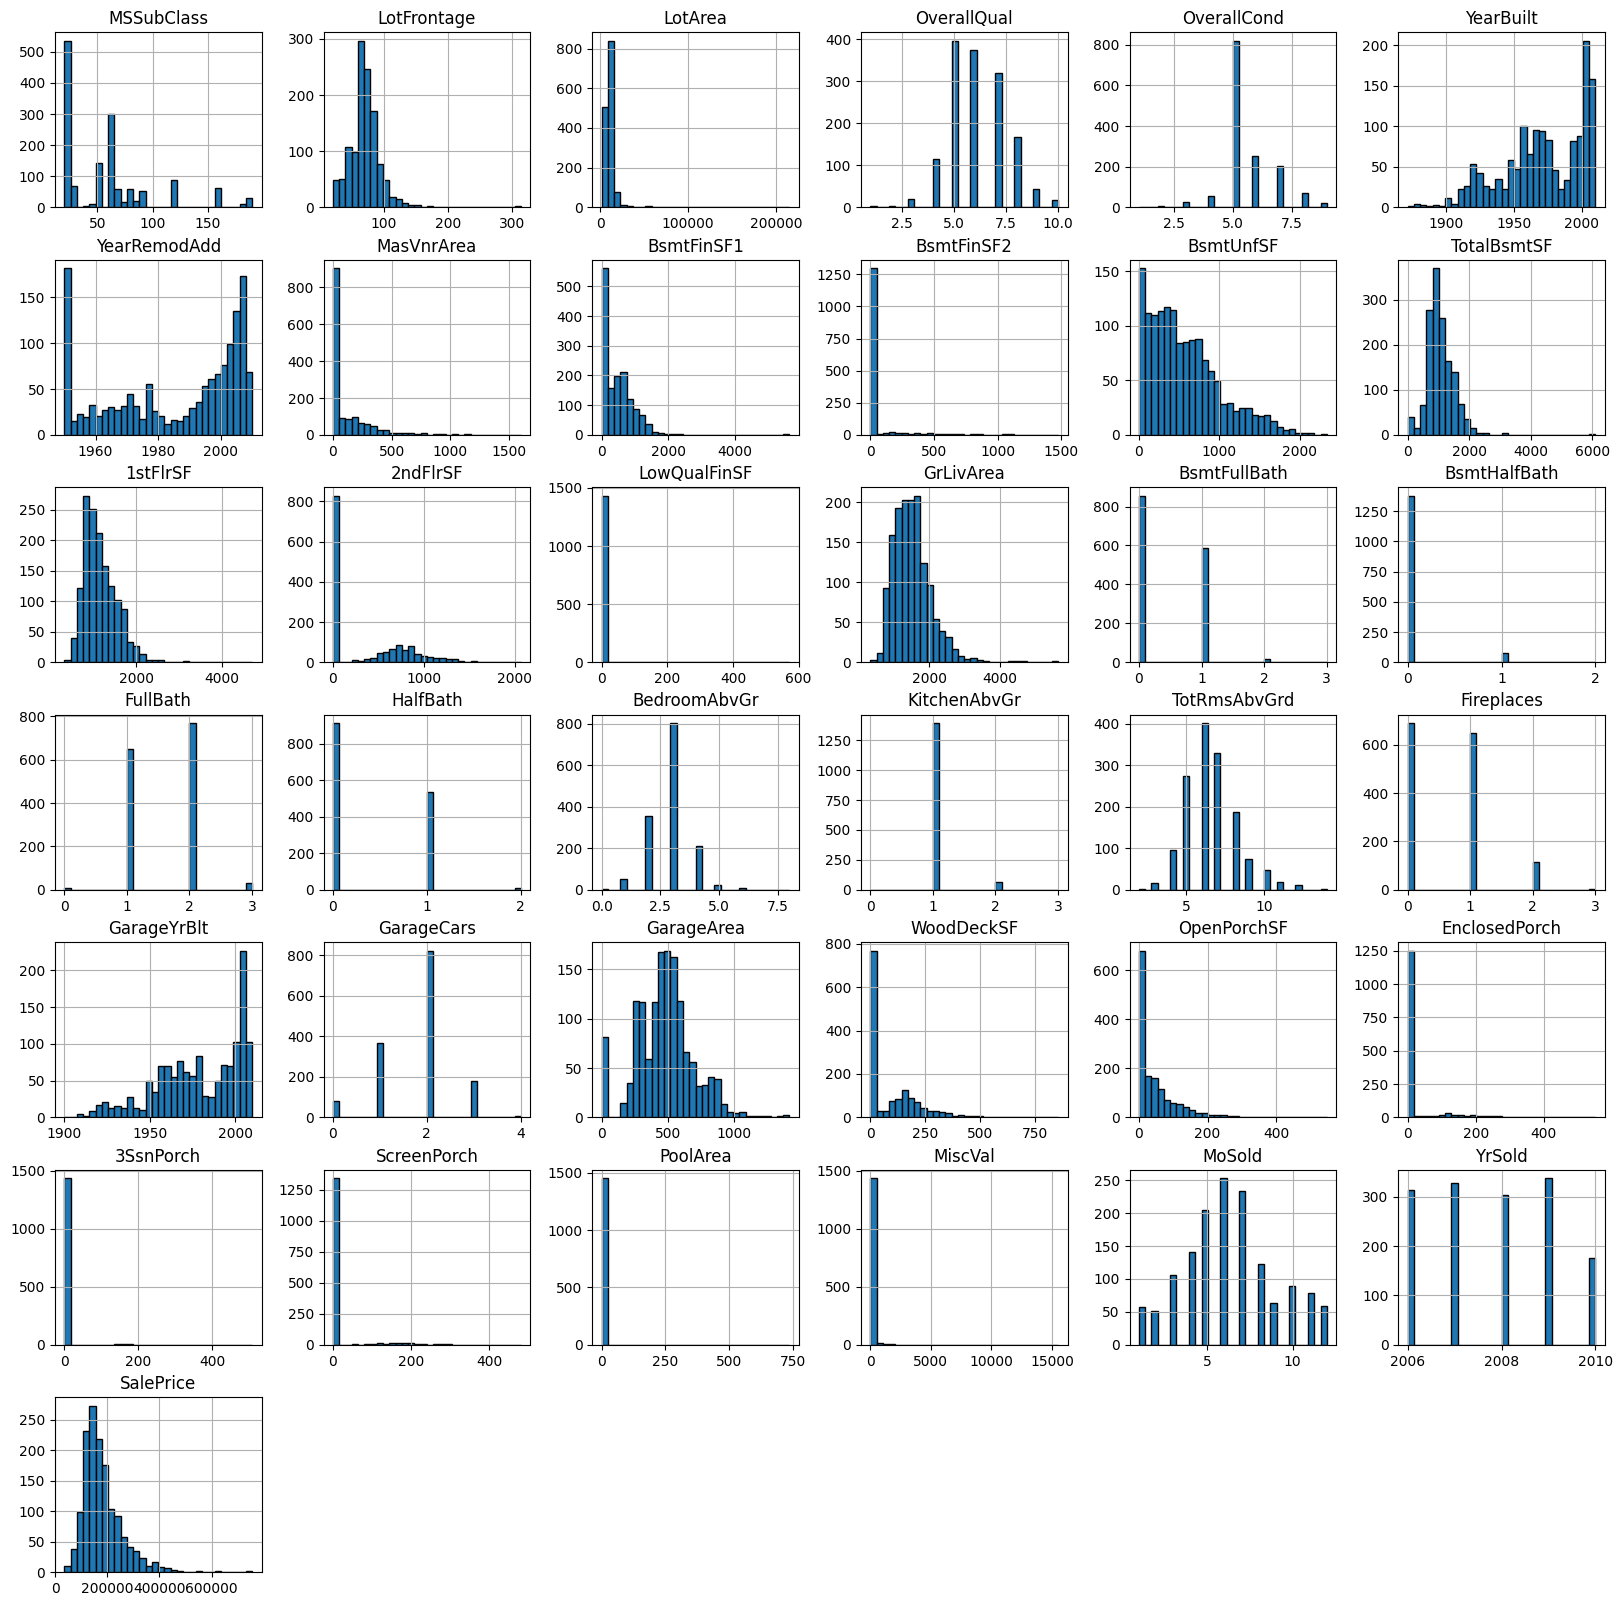

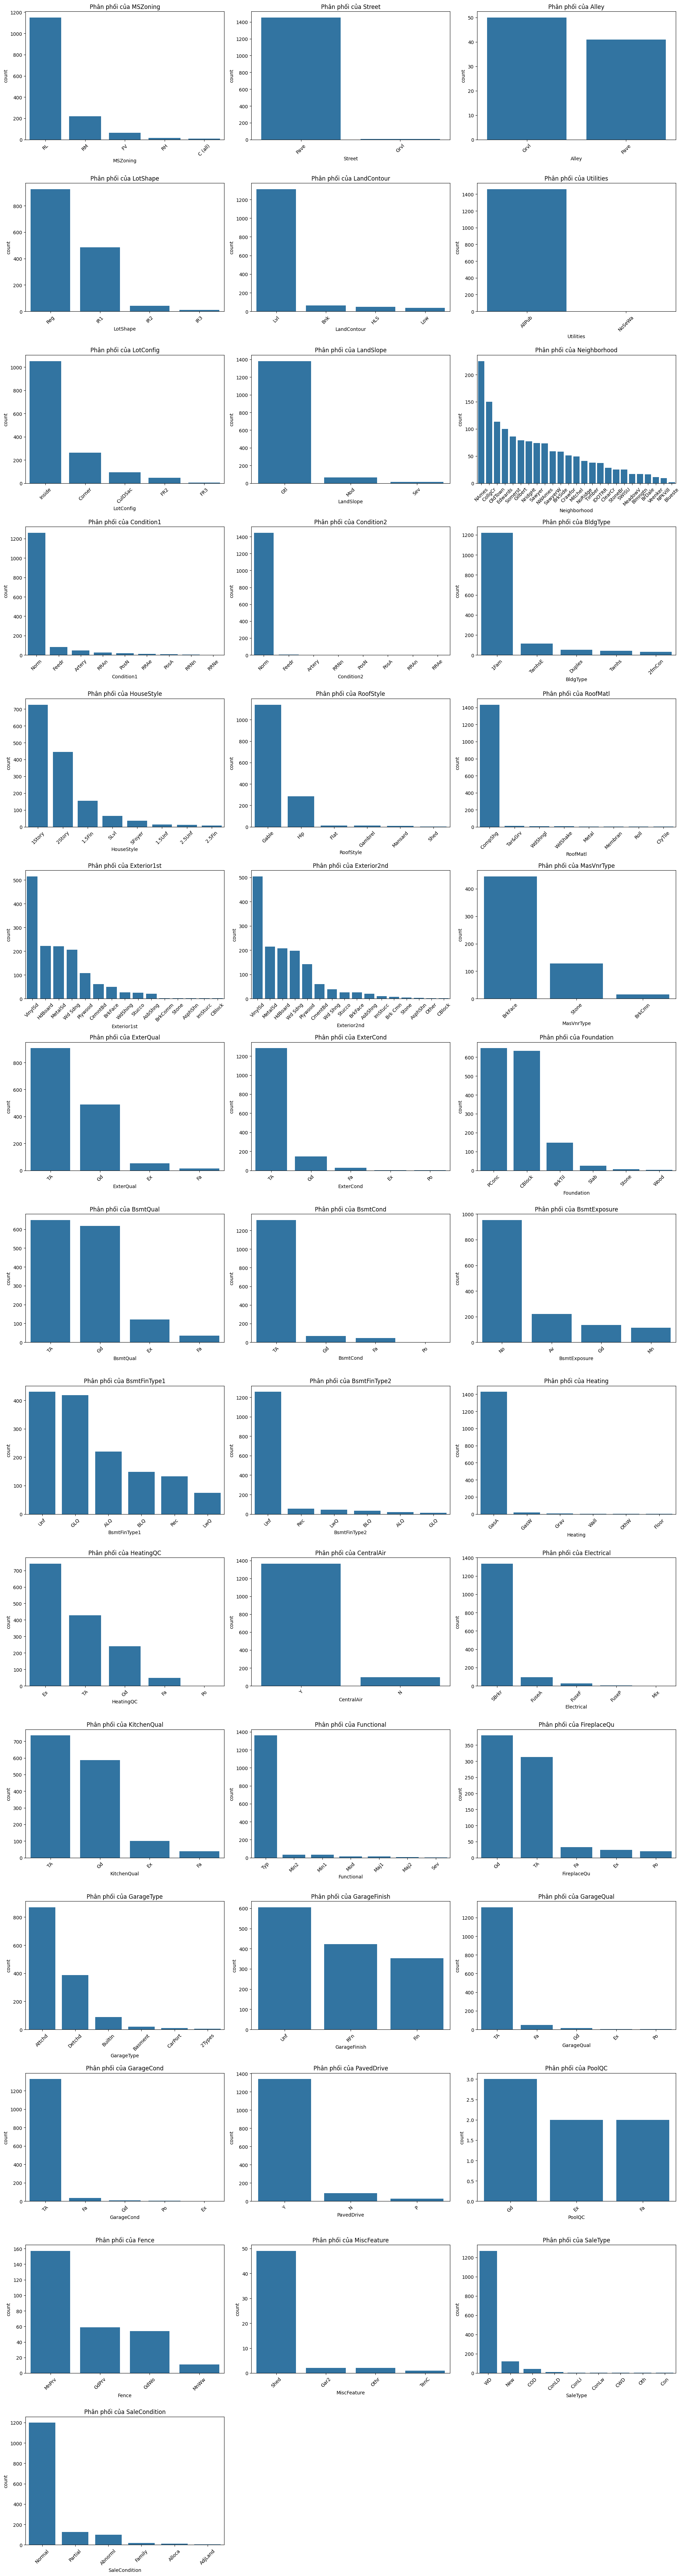

In [4]:
_ = train_df.hist(figsize=(20, 20), bins=30, edgecolor='black')
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns
cols_per_row = 3
rows = math.ceil(len(cat_cols) / cols_per_row)
_ = plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(cat_cols):
    _ = plt.subplot(rows, cols_per_row, i + 1)
    _ = sns.countplot(data=train_df, x=col, order=train_df[col].value_counts().index)
    _ = plt.xticks(rotation=45)
    _ = plt.title(f'Phân phối của {col}')
plt.tight_layout()
plt.show()



In [5]:
filterred = train_df.loc[train_df["Street"]=="Pave","Street"]
filterred.shape
filterred = train_df.loc[train_df["Utilities"]=="AllPub","Utilities"]
filterred.shape

(1454,)

(1459,)

Dựa vào các biểu đồ ta thấy LotArea xuất hiện các giá trị lớn bất thường, 1 số thuộc tính bị lệch hẳn sang giá trị 0. Xem xét kĩ hơn ta thấy 2 thuộc tính Street và Utilities có varience rất thấp, 1 số cột khác tuy cũng có varience rất thấp nhưng liên quan tới đặc tính ngôi nhà ảnh hưởng trực tiếp tới giá cả. Có thể loại các cột PoolQC, Street và Utilities

# Điền giá trị trống
Dựa vào mô tả của tập dữ liệu, ta thấy 1 số cột giá trị trống có ý nghĩa là 0, trong khi đó 1 số cột là thiếu dữ liệu. Ngoài ra với 1 số cột như MasVnrArea và MasVnrType việc điền hoặc bỏ trống còn phụ thuộc vào giá trị cột còn lại

In [6]:
def fill_na(df):
    filled_df = df.copy()
    cols_none = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2','Fence'
    ]
    for col in cols_none:
        filled_df[col] = filled_df[col].fillna('None')

    filled_df['GarageYrBlt'] = filled_df['GarageYrBlt'].fillna(filled_df['YearBuilt'])
    filled_df['GarageCars'] = filled_df['GarageCars'].fillna(0)
    filled_df['GarageArea'] = filled_df['GarageArea'].fillna(0)


    filled_df['LotFrontage'] = filled_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    filled_df['Electrical'] = filled_df['Electrical'].fillna(filled_df['Electrical'].mode()[0])
    '''
    Với masVnrType điền giá trị phổ biến nhất nếu area > 0
    Với masVnrArea điền giá trị trung vị theo loại tường nếu type != None
    Còn lại điền None và 0
    '''
    filled_df.loc[
        filled_df['MasVnrType'].isna() & (filled_df['MasVnrArea'] > 0), 
        'MasVnrType'
        ] = filled_df[filled_df['MasVnrType'] != 'None']['MasVnrType'].mode()[0]

    mask2 = (filled_df['MasVnrArea'].isna()) & (filled_df['MasVnrType'].notna())
    avg_area_map = filled_df.groupby('MasVnrType')['MasVnrArea'].mean()
    filled_df.loc[mask2, 'MasVnrArea'] = filled_df.loc[mask2, 'MasVnrType'].map(avg_area_map)
    filled_df['MasVnrType'] = filled_df['MasVnrType'].fillna('None')
    filled_df['MasVnrArea'] = filled_df['MasVnrArea'].fillna(0)
    
    filled_df['BsmtFinSF1'] = filled_df['BsmtFinSF1'].fillna(0)
    filled_df['BsmtFinSF2'] = filled_df['BsmtFinSF2'].fillna(0)
    filled_df['BsmtUnfSF'] = filled_df['BsmtUnfSF'].fillna(0)
    filled_df['TotalBsmtSF'] = filled_df['TotalBsmtSF'].fillna(0)
    filled_df['MSZoning'] = filled_df['MSZoning'].fillna(filled_df['MSZoning'].mode()[0])
    filled_df['Exterior1st'] = filled_df['Exterior1st'].fillna(filled_df['Exterior1st'].mode()[0])
    filled_df['Exterior2nd'] = filled_df['Exterior2nd'].fillna(filled_df['Exterior2nd'].mode()[0])
    filled_df['SaleType'] = filled_df['SaleType'].fillna(filled_df['SaleType'].mode()[0])
    filled_df['Utilities'] = filled_df['Utilities'].fillna(filled_df['Utilities'].mode()[0])
    filled_df['KitchenQual'] = filled_df['KitchenQual'].fillna(filled_df['KitchenQual'].mode()[0])
    filled_df['Functional'] = filled_df['Functional'].fillna(filled_df['Functional'].mode()[0])
    filled_df['BsmtHalfBath'] = filled_df['BsmtHalfBath'].fillna(0)
    filled_df['BsmtFullBath'] = filled_df['BsmtFullBath'].fillna(0)
    filled_df['BsmtFullBath'] = filled_df['BsmtFullBath'].fillna(0)
    filled_df['BsmtHalfBath'] = filled_df['BsmtHalfBath'].fillna(0)
    return filled_df

# Tìm và loại outlier

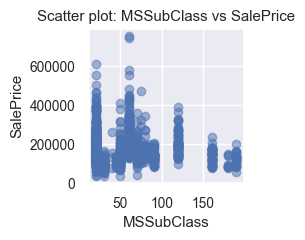

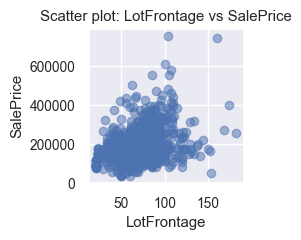

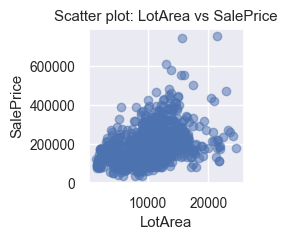

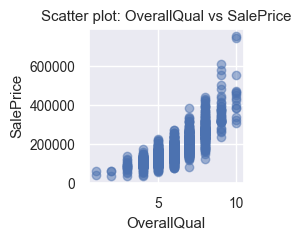

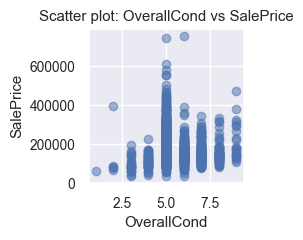

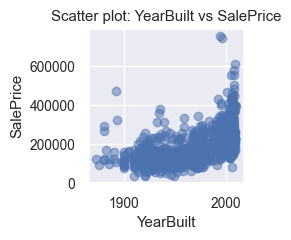

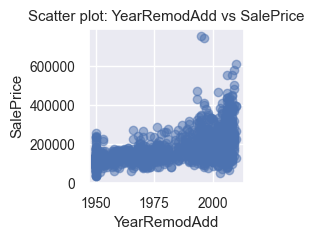

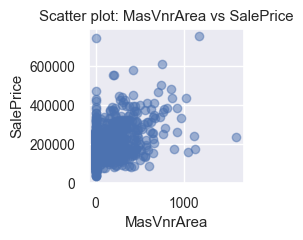

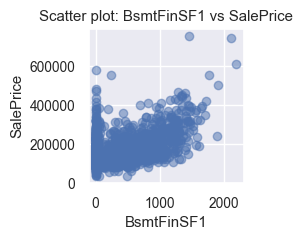

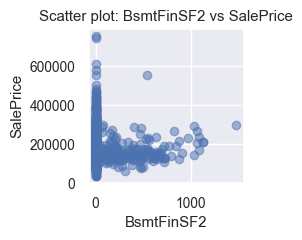

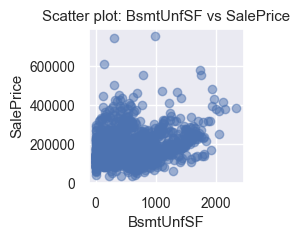

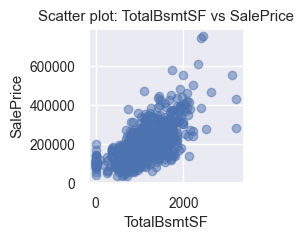

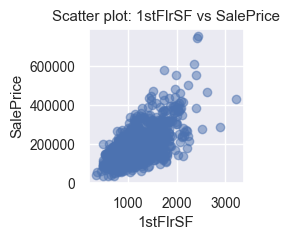

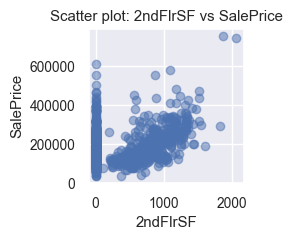

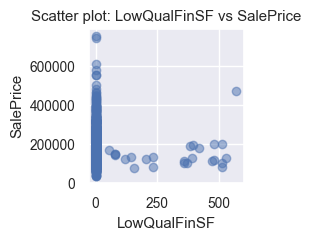

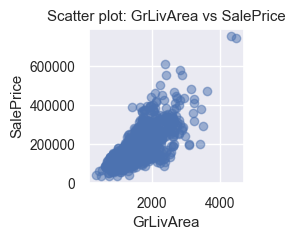

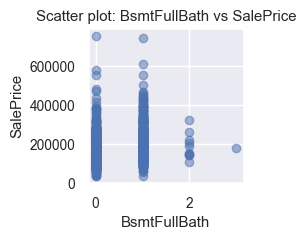

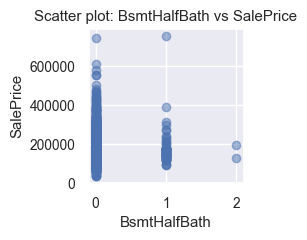

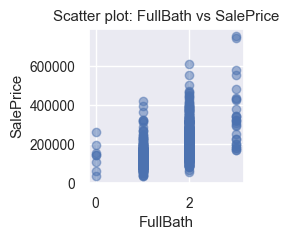

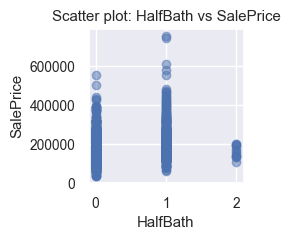

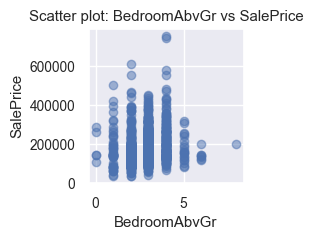

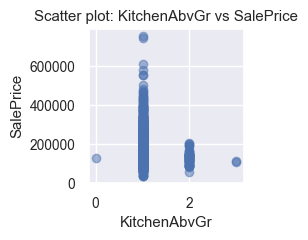

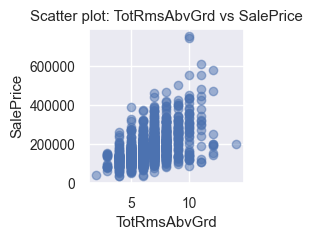

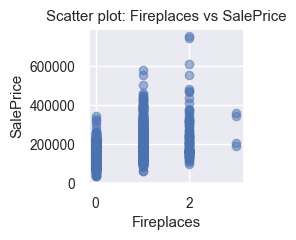

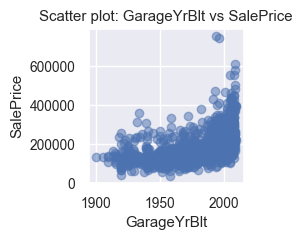

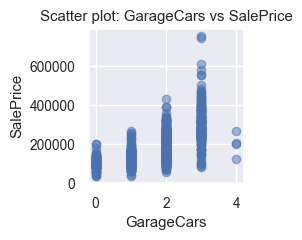

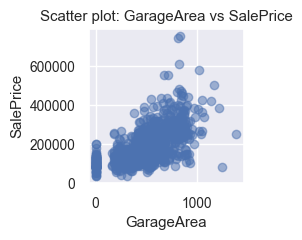

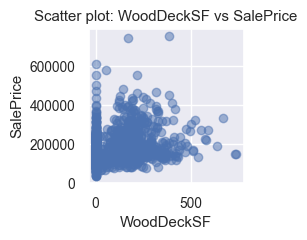

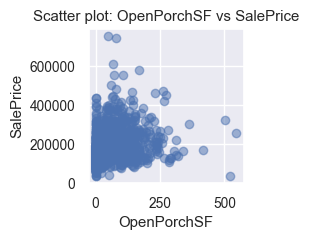

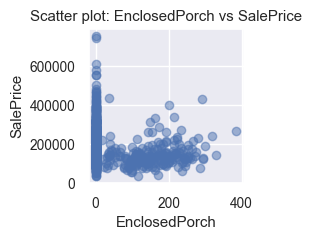

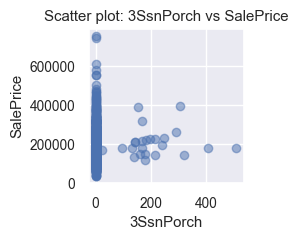

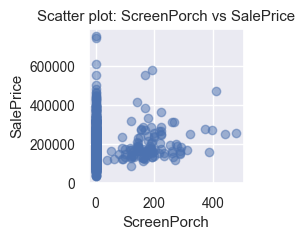

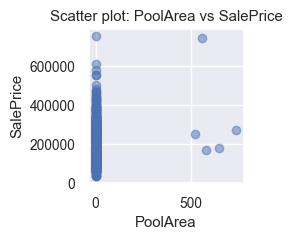

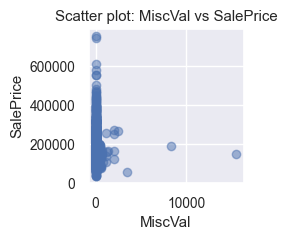

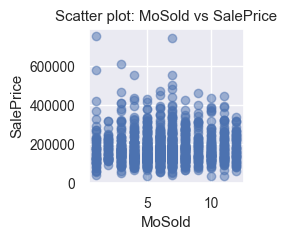

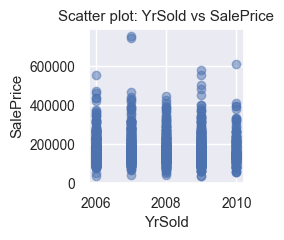

In [15]:
df_num = train_df.select_dtypes(include=['float64', 'int64'])
for col in df_num.columns:
    if col != 'SalePrice':
        _ = plt.figure(figsize=(2,2))
        _ = plt.scatter(df_num[col], df_num['SalePrice'], alpha=0.5)
        _ = plt.xlabel(col)
        _ = plt.ylabel('SalePrice')
        _ = plt.title(f'Scatter plot: {col} vs SalePrice')
        plt.show()

Ta áp dụng IQR cho các cột LotArea, GrLivArea, TotalBsmtSF, LotFrontage

In [8]:
def remove_outliers_iqr(df, column_name, factor=1.5):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    df_out = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    return df_out

# ENCODE các giá trị chữ

Ta sử dụng Ordinal Encoding cho dữ liệu có dạng thứ tự, những dữ liệu còn lại ta sử dụng One-Hot encoding

In [9]:
def encode(df):
    encoded_df = df.copy()
    qual_mapping = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    for col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']:
        encoded_df[col] = encoded_df[col].apply(str.strip).map(qual_mapping)
    qual_mapping = {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3}
    encoded_df['LotShape'] = encoded_df['LotShape'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'ELO': 0, 'NoSeWa': 1, 'NoSewr': 2, 'AllPub': 3}
    encoded_df['Utilities'] = encoded_df['Utilities'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'Sev': 0, 'Mod': 1, 'Gtl': 2}
    encoded_df['LandSlope'] = encoded_df['LandSlope'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'Gd': 4, 'Av': 3, 'Mn':2, 'No':1, 'None':0}
    encoded_df['BsmtExposure'] = encoded_df['BsmtExposure'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
    for col in ['BsmtFinType1', 'BsmtFinType2']:
        encoded_df[col] = encoded_df[col].apply(str.strip).map(qual_mapping)
    qual_mapping = {'Y': 1, 'N': 0}
    encoded_df['CentralAir'] = encoded_df['CentralAir'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
    encoded_df['Functional'] = encoded_df['Functional'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
    encoded_df['GarageFinish'] = encoded_df['GarageFinish'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'Y': 2, 'P': 1, 'N': 0}
    encoded_df['PavedDrive'] = encoded_df['PavedDrive'].apply(str.strip).map(qual_mapping)
    qual_mapping = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}
    encoded_df['Fence'] = encoded_df['Fence'].apply(str.strip).map(qual_mapping)
    remaining_obj_cols = encoded_df.select_dtypes(include=['object']).columns
    encoded_df = pd.get_dummies(encoded_df, columns=remaining_obj_cols, drop_first=True)
    return encoded_df

C:\Users\minhh\AppData\Local\Temp\ipykernel_6824\3795885877.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_obj_cols = encoded_df.select_dtypes(include=['object']).columns


<Figure size 1300x1100 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap Group 1: SalePrice & Features 1 to 15')

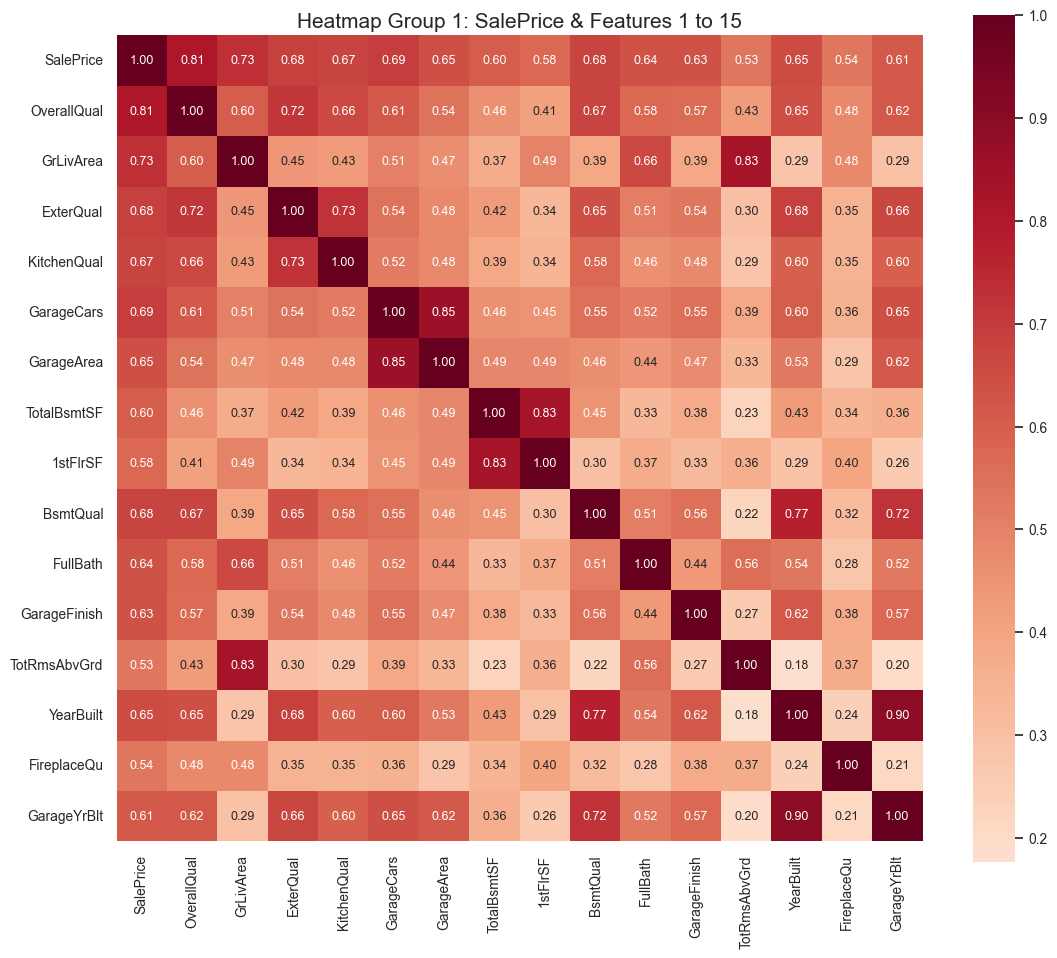

<Figure size 1300x1100 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap Group 2: SalePrice & Features 16 to 30')

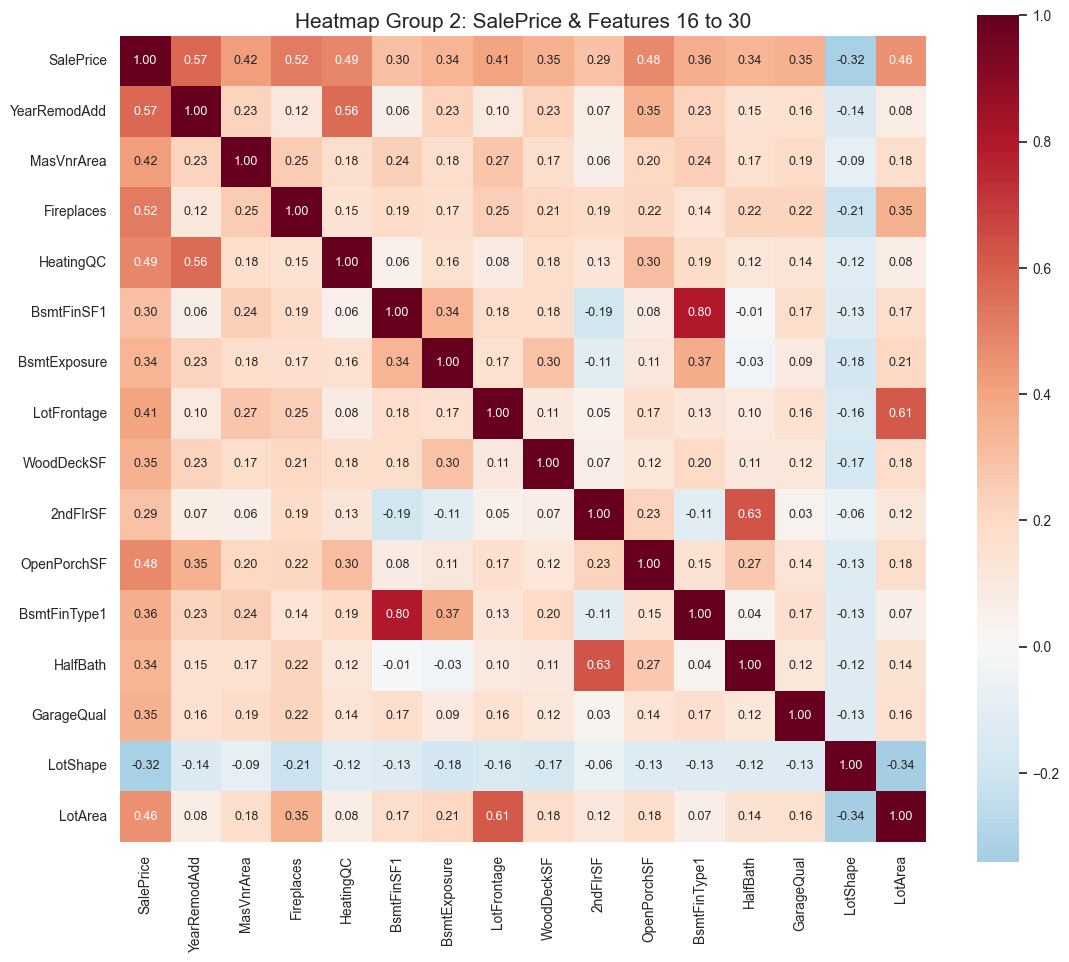

<Figure size 1300x1100 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap Group 3: SalePrice & Features 31 to 45')

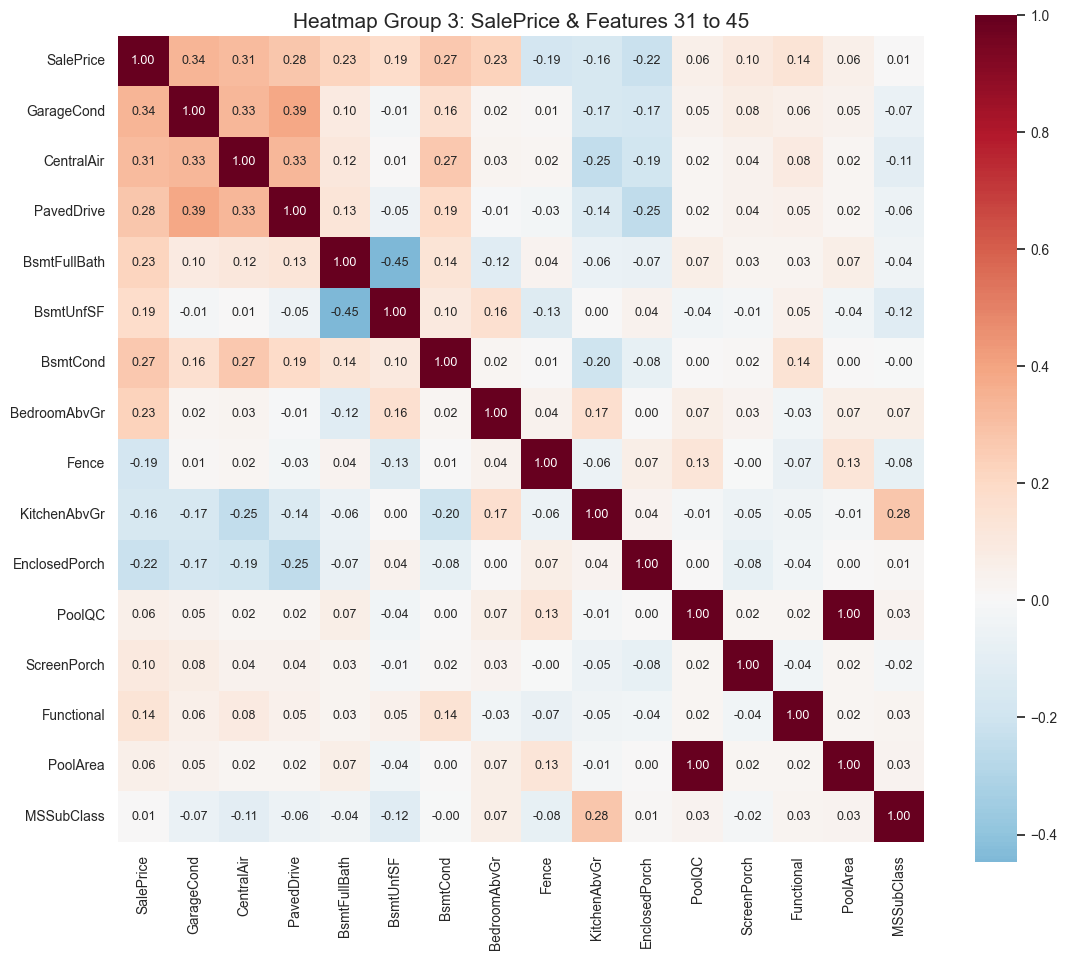

<Figure size 1300x1100 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Heatmap Group 4: SalePrice & Features 46 to 57')

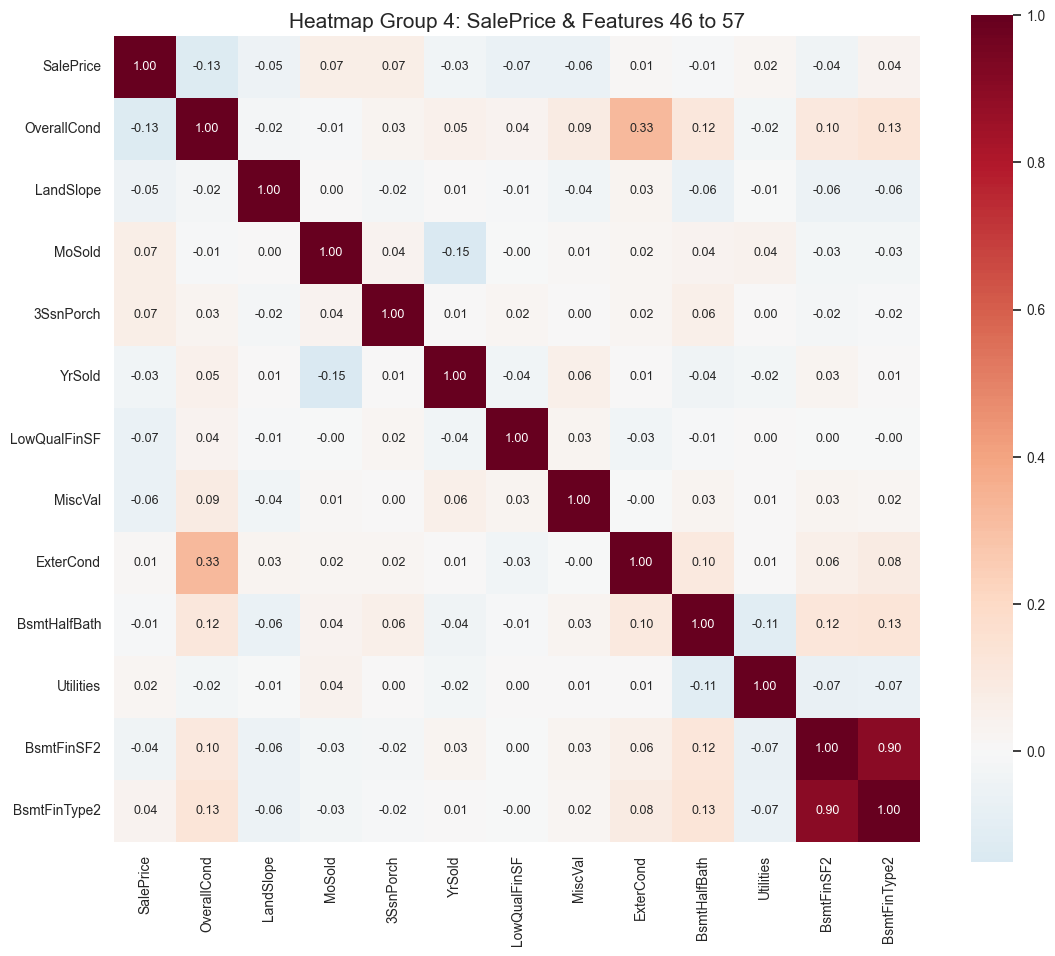

In [10]:
df = encode(fill_na(train_df))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
all_sorted_cols = corr_matrix['SalePrice'].abs().sort_values(ascending=False).index.tolist()
target = 'SalePrice'
other_features = [col for col in all_sorted_cols if col != target]
chunk_size = 15
groups = [other_features[i:i + chunk_size] for i in range(0, len(other_features), chunk_size)]
for i, group in enumerate(groups):
    current_cols = [target] + group
    cm = df[current_cols].corr(method='spearman')
    plt.figure(figsize=(13, 11))
    sns.set(font_scale=0.9)
    
    sns.heatmap(cm, 
                cbar=True, 
                annot=True, 
                square=True, 
                fmt='.2f', 
                annot_kws={'size': 9}, 
                yticklabels=current_cols, 
                xticklabels=current_cols,
                cmap='RdBu_r', 
                center=0)
    
    start_num = i * chunk_size + 1
    end_num = min((i + 1) * chunk_size, len(other_features))
    plt.title(f'Heatmap Group {i+1}: SalePrice & Features {start_num} to {end_num}', fontsize=15)
    plt.show()

# Feature extract
Chúng ta loại bỏ 1 số cột không cần thiết và tính toán thêm các thông tin quan trọng như tổng diện tích...

In [11]:
def extract_features(df):
    features = df.copy()
    cols_to_drop = ['Utilities', 'Street', 'PoolQC']
    features = features.drop(columns=cols_to_drop, axis=1)
    # Tổng diện tích sàn 
    features['TotalSF'] = (features['TotalBsmtSF'] + 
                           features['1stFlrSF'] + 
                           features['2ndFlrSF'])

    # Tổng diện tích sàn hoàn thiện 
    features['Total_sqr_footage'] = (features['BsmtFinSF1'] + 
                                     features['BsmtFinSF2'] +
                                     features['1stFlrSF'] + 
                                     features['2ndFlrSF'])

    # Tổng số phòng tắm
    features['Total_Bathrooms'] = (features['FullBath'] + (0.5 * features['HalfBath']) +
                                   features['BsmtFullBath'] + (0.5 * features['BsmtHalfBath']))

    # Tổng diện tích hiên và ban công
    features['Total_porch_sf'] = (features['OpenPorchSF'] + 
                                  features['3SsnPorch'] +
                                  features['EnclosedPorch'] + 
                                  features['ScreenPorch'] +
                                  features['WoodDeckSF'])

    return features

# Xử lí và lưu dữ liệu sau xử lí

In [16]:
train_df["SalePrice"] = np.log1p(train_df["SalePrice"])
train_df = train_df[train_df['LotArea'] < 25000]
filled_train = fill_na(train_df)
filled_test = fill_na(test_df)
encoded_train = encode(filled_train)
encoded_test = encode(filled_test)
save_path = "../data/processed"
os.makedirs(save_path, exist_ok=True)
train_IQR = encode(fill_na(train_df))
for col in ['LotArea', 'LotFrontage', 'GrLivArea']:
    train_IQR = remove_outliers_iqr(train_IQR, col)
encoded_train.to_csv(os.path.join(save_path, "train.csv"), index=False)
encoded_test.to_csv(os.path.join(save_path, "test.csv"), index=False)
train_IQR.to_csv(os.path.join(save_path, "train_no_outlier_IQR.csv"), index=False)

C:\Users\minhh\AppData\Local\Temp\ipykernel_6824\3795885877.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_obj_cols = encoded_df.select_dtypes(include=['object']).columns
C:\Users\minhh\AppData\Local\Temp\ipykernel_6824\3795885877.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.o